## Modelling - BactHeCom
This scripts contains the code for computing and evaluating different model algorithms to predict mortality at 30 days

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
DATA_DIR = "../data"
RESULTS_DIR = "../results"

os.makedirs(f"{RESULTS_DIR}/model/selection_model", exist_ok=True)

### Load data

In [3]:
### Load merged df
df = pd.read_csv(f"{DATA_DIR}/preprocessed_db.csv")
df.head()

,record_id,sexo,fecha_ingreso,fecha_alta,IRAs_nosocomial,mortalidad,mortalidad_30_dias,uci_por_el_episodio,duracion_UCI,mujer_gestante,...,sonda_urinaria,sonda_nasogastrica,derivacion_ventriculoper,valvula_prot_cardiaca,portador_otros_disposit,antimicrobiano_list,cmi_list,interpretacion_list,antimicrobiano_family_list,ingreso_prev_indicator
0,1,0,2021-08-24,2021-09-09,1,1,1,1,14,0,...,0,1,0,0,0,"['Cefazolina', 'Trimetoprim', 'Ertapenem', 'Ce...","['>16 mg/L', '>4 mg/L', '>1 mg/L', '>8 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'I', ...","['Cefalosporin', 'TMP_SMX', 'Carbapenem', 'Cef...",0
1,2,1,2023-06-18,2023-07-13,1,0,0,1,3,0,...,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Cefuroxima', ...","['>4/76 mg/L', '<=8 mg/L', '0.5 mg/L', '<=0.5 ...","['R', 'I', 'I', 'S', 'S', 'S', 'S', 'S', 'S', ...","['TMP_SMX', 'Cefalosporin', 'Quinolone', 'Quin...",0
2,3,0,2022-02-11,2022-04-06,1,0,0,1,24,0,...,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Ampicilina', ...","['>4/76 mg/L', '>8 mg/L', '>4 mg/L', '>1 mg/L'...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Penicillin', 'Aminoglycoside', 'Q...",1
3,4,0,2021-05-15,2021-07-28,1,0,0,1,42,0,...,0,1,0,0,0,"['Trimetoprim', 'Levofloxacino', 'Ertapenem', ...","['>4 mg/L', '>1 mg/L', '>1 mg/L', '>16 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Quinolone', 'Carbapenem', 'Cefalo...",1
4,5,1,2021-07-04,2022-01-04,1,0,0,1,78,0,...,0,0,0,0,0,"['Aztreonam', 'Ciprofloxacino', 'Ceftazidima',...","['<=1 mg/L', '>1 mg/L', '<=1 mg/L', '>8 mg/L',...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['Monobactam', 'Quinolone', 'Cefalosporin', 'C...",0


### Mortality imbalance

In [4]:
print(f"Mortality at 30 days: {df['mortalidad_30_dias'].sum()/df.shape[0]*100:.2f}% of total records")  # target prevalence

Mortality at 30 days: 18.02% of total records


### Target and non-target columns

In [5]:
df.shape

(3985, 131)

In [6]:
TARGET = "mortalidad_30_dias"

NONTARGETCOLS = ["record_id", "episode_id", "fecha_ingreso", "fecha_alta","mortalidad",
             "microorganismos_dict", "fechas_dict", "especimen_dict", "antimicrobiano_list", "cmi_list",
             "interpretacion_list", "antimicrobiano_family_list"]

df_ = df.drop(columns=NONTARGETCOLS) 

## Data Preprocessing

In [7]:
# Prepare data
X = df_.drop(columns=[TARGET])
y = df_[TARGET]

### Split data into train and tests sets
- Train / Validation: **70%** (80% train, 20% validation)
- Test: **30%**

In [8]:
# Split train ans test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99, stratify=y) # statify to preserve target distribution

### Models
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- SVC

In [9]:
models = {
    "Logistic_Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ]),
    "Random_Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        auto_class_weights="Balanced",
        verbose=0,
        random_state=42,
        allow_writing_files=False 
    ),
    "SVC": Pipeline([
        ("scaler", StandardScaler()),   # SVC needs scaled features
        ("svc", SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

### Train and predict models

In [10]:
results = {}
y_pred_probs = {}
y_pred_classes = {}

for threshold in [0.1, 0.25, 0.5]:

    for name, model in models.items():
        # Fit model
        model.fit(X_train, y_train)

        # Predict probabilities
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred_probs[name] = y_prob

        # Convert probabilities to class labels (default threshold 0.5)
        y_pred = (y_prob >= threshold).astype(int)
        y_pred_classes[name] = y_pred

        # Compute metrics
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        results[name] = {
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "F1": f1,
            "Precision": precision,
            "Recall": recall
        }

    # Convert to DataFrame
    results_df = pd.DataFrame(results).T
    results_df.to_csv(f"{RESULTS_DIR}/model/selection_model/model_stats_threshold_{threshold}.csv")

    print(results_df)
    print("\nBest F1-scores:")
    print(results_df['F1'].sort_values(ascending=False))


                      ROC-AUC    PR-AUC        F1  Precision    Recall
Logistic_Regression  0.764085  0.398868  0.329466   0.197588  0.990698
Random_Forest        0.795183  0.478582  0.306152   0.180896  0.995349
XGBoost              0.779608  0.498804  0.418981   0.278891  0.841860
LightGBM             0.784107  0.515832  0.437158   0.309478  0.744186
CatBoost             0.791186  0.512734  0.391773   0.248139  0.930233
SVC                  0.784932  0.448235  0.428413   0.281341  0.897674

Best F1-scores:
LightGBM               0.437158
SVC                    0.428413
XGBoost                0.418981
CatBoost               0.391773
Logistic_Regression    0.329466
Random_Forest          0.306152
Name: F1, dtype: float64
                      ROC-AUC    PR-AUC        F1  Precision    Recall
Logistic_Regression  0.764085  0.398868  0.381232   0.241337  0.906977
Random_Forest        0.795183  0.478582  0.373665   0.231023  0.976744
XGBoost              0.779608  0.498804  0.455696   0.34

### Best F1-scores models:
- **XGBoost**
- **CatBoost**
- **LightGBM**

### Plot ROC and PR curves

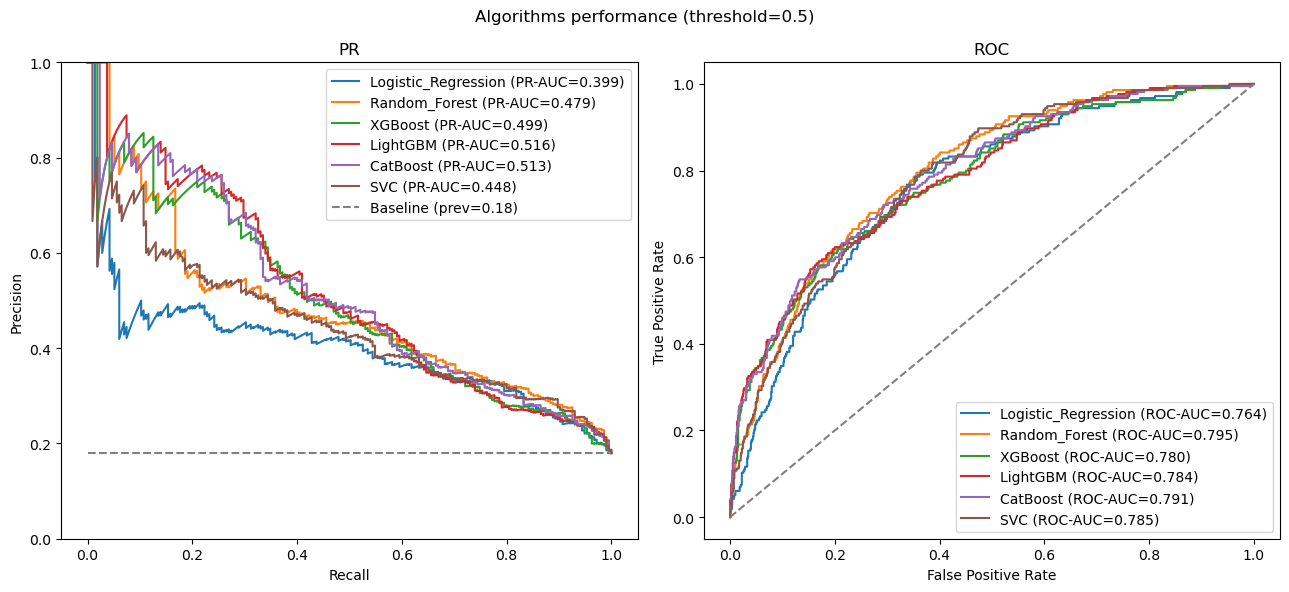

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

# Precision–Recall
for name, y_prob in y_pred_probs.items():
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

    ax[0].plot(
        recall,
        precision,
        label=f"{name} (PR-AUC={results[name]['PR-AUC']:.3f})"
    )

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_ylim(0, 1)
ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("PR")
ax[0].legend()

# ROC
for name, y_prob in y_pred_probs.items():
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

    ax[1].plot(
        fpr,
        tpr,
        label=f"{name} (ROC-AUC={results[name]['ROC-AUC']:.3f})"
    )

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC")
ax[1].legend()

plt.suptitle("Algorithms performance (threshold=0.5)")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/selection_model/pr_roc_models_curves.png")
plt.show()


### Confusion matrix

In [12]:
thresholds = [0.1, 0.25, 0.5]
cm_results = {}

for threshold in thresholds:
    for name, y_prob in y_pred_probs.items():
        # Convert probabilities to class labels
        y_pred = (y_prob >= threshold).astype(int)
        
        # Compute confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        cm_results[name] = cm
        
        # Optional: display
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(cmap=plt.cm.Blues)
        plt.xlabel("")
        plt.ylabel("")
        plt.xticks([0, 1], labels=['Predicted_No_Mortality', 'Predicted_Mortality'])
        plt.yticks([0, 1], labels=['True_No_Mortality', 'True_Mortality'])

        plt.title(f"{name} - (threshold={threshold})")
        os.makedirs(f"{RESULTS_DIR}/model/selection_model/confusion_matrix", exist_ok=True)
        plt.savefig(f"{RESULTS_DIR}/model/selection_model/confusion_matrix/{name}_threshold_{threshold}.png")
        plt.close()